# Euclidean Distance Analysis
An interactive exploration of Euclidean distance calculations using pure Python, optimized NumPy vectorization, and visualization.

## Definition
The Euclidean distance between two points $P = (p_1, p_2, \dots, p_n)$ and $Q = (q_1, q_2, \dots, q_n)$ in Euclidean $n$-space is defined as:
$$d(P, Q) = \sqrt{\sum_{i=1}^n (p_i - q_i)^2}$$


## Setup Instructions (Conda Environment)
To set up a Conda environment with all the necessary packages to run this notebook, execute the following commands in your terminal:

```bash
# 1. Create a new Conda environment named 'distance_env' with Python 3.12
conda create -n distance_env python=3.12 -y

# 2. Activate the environment
conda activate distance_env

# 3. Install the required packages via conda-forge
conda install -c conda-forge numpy pandas scipy matplotlib notebook ipykernel -y
```

Alternatively, if you prefer installing packages via `pip`:
```bash
conda create -n distance_env python=3.12 -y
conda activate distance_env
pip install numpy pandas scipy matplotlib notebook ipykernel
```


### 1. Pure Python Implementation
Let's start by implementing the distance formula using pure Python list comprehension and the standard `math` library.


In [1]:
import math

def euclidean_distance_python(p, q):
    """Calculate Euclidean distance between two points using pure Python."""
    if len(p) != len(q):
        raise ValueError("Points must have the same dimensions")
    return math.sqrt(sum((pi - qi) ** 2 for pi, qi in zip(p, q)))

# Test points
p1 = (1.0, 2.0, 3.0)
p2 = (4.0, 5.0, 6.0)
dist_py = euclidean_distance_python(p1, p2)
print(f"Point 1: {p1}")
print(f"Point 2: {p2}")
print(f"Distance (Python): {dist_py:.6f}")


Point 1: (1.0, 2.0, 3.0)
Point 2: (4.0, 5.0, 6.0)
Distance (Python): 5.196152


### 2. NumPy Implementation
NumPy allows us to vectorize this calculation, which is much faster and cleaner, especially for high-dimensional data or large arrays.


In [2]:
import numpy as np

def euclidean_distance_numpy(p, q):
    """Calculate Euclidean distance using NumPy vectorization."""
    p_arr = np.asarray(p)
    q_arr = np.asarray(q)
    return np.linalg.norm(p_arr - q_arr)

dist_np = euclidean_distance_numpy(p1, p2)
print(f"Distance (NumPy): {dist_np:.6f}")


Distance (NumPy): 5.196152


### 3. Performance Comparison
Let's benchmark the two implementations using high-dimensional random vectors to see the difference in execution speed. We will use `%timeit` to run them multiple times.


In [3]:
import random

# Generate two high-dimensional vectors (dimension = 100,000)
dim = 100000
vec1 = [random.random() for _ in range(dim)]
vec2 = [random.random() for _ in range(dim)]

# Convert to numpy arrays for the NumPy run
vec1_np = np.array(vec1)
vec2_np = np.array(vec2)

print(f"Benchmarking with dimension = {dim:,}")
print("-" * 40)

print("Benchmarking Pure Python:")
%timeit euclidean_distance_python(vec1, vec2)

print("\nBenchmarking NumPy (np.linalg.norm):")
%timeit np.linalg.norm(vec1_np - vec2_np)


Benchmarking with dimension = 100,000
----------------------------------------
Benchmarking Pure Python:
8.6 ms ± 129 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)

Benchmarking NumPy (np.linalg.norm):
217 μs ± 19.6 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


### 4. 2D Visual Demonstration
Let's visualize a reference point and multiple random points in 2D space, color-coding them by their Euclidean distance from the reference to build an intuitive visual map.


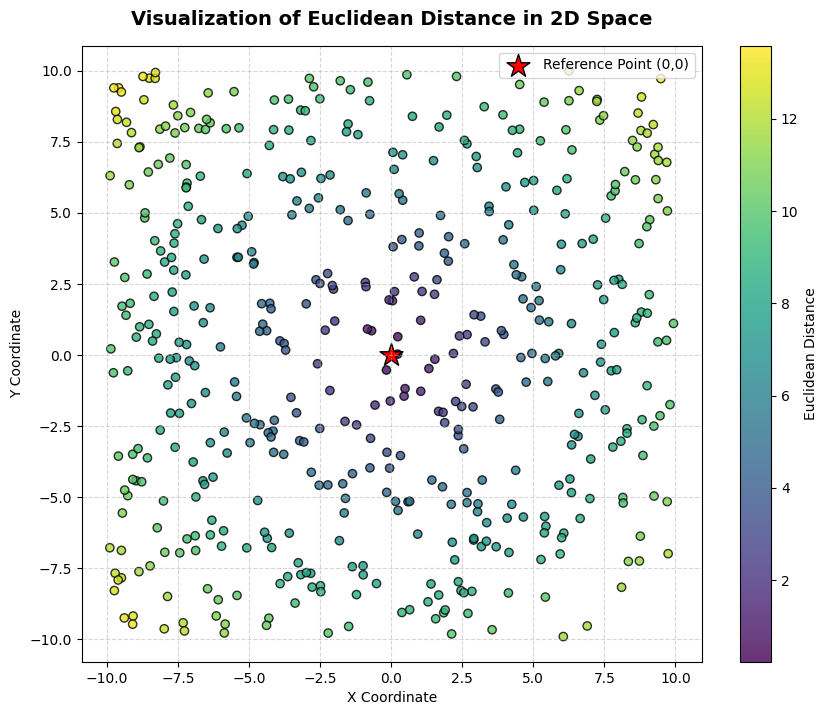

In [4]:
import matplotlib.pyplot as plt

# Generate a reference point
ref_point = np.array([0, 0])

# Generate 500 random points in 2D space
np.random.seed(42)
points = np.random.uniform(-10, 10, (500, 2))

# Compute distances from reference
distances = np.linalg.norm(points - ref_point, axis=1)

# Plotting the distance gradient map
plt.figure(figsize=(10, 8), dpi=100)
sc = plt.scatter(points[:, 0], points[:, 1], c=distances, cmap='viridis', edgecolor='k', alpha=0.8)
plt.scatter(ref_point[0], ref_point[1], color='red', marker='*', s=300, label='Reference Point (0,0)', edgecolor='black')

plt.colorbar(sc, label='Euclidean Distance')
plt.title('Visualization of Euclidean Distance in 2D Space', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('X Coordinate')
plt.ylabel('Y Coordinate')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.axis('equal')
plt.show()


### 5. Loading 3D Point Cloud Data and Visualizing in 2D
We will load the 3D point cloud dataset from `point_cloud_dataset.csv` (which contains 3D coordinates `x`, `y`, `z`, a ground-truth flag `gt`, and a `cluster` column). For visual ease and rendering performance, we will visualize this 3D data using a 2D projection (plotting `x` vs. `y`). We also set an equal aspect ratio to keep the visual proportions of the coordinates correct.


In [5]:
import pandas as pd

# Load the dataset
df = pd.read_csv("point_cloud_dataset.csv")

# Display first few rows
df.head()


,x,y,z,time-point,gt,cluster
0,26318.730897,22121.150606,1627.159526,6,1,12
1,24020.309892,23723.468690,586.890480,5,0,-1
2,25193.940609,21035.339624,1031.285922,1,1,1
3,25383.669443,14878.767855,577.998138,3,0,-1
4,24787.191333,15449.533691,1542.088074,9,1,18


In [6]:
# Display statistics of the dataset
df.describe()


,x,y,z,time-point,gt,cluster
count,272022.000000,272022.000000,272022.000000,272022.000000,272022.000000,272022.000000
mean,24997.084784,21433.402952,1286.266152,3.995828,0.323584,2.721217
std,2037.928119,4292.310741,715.776992,2.475971,0.467844,6.478500
min,20000.078213,12000.271665,-401.974306,0.000000,0.000000,-1.000000
25%,23643.548999,18235.159434,771.517083,2.000000,0.000000,-1.000000
50%,24993.949731,21291.434952,1292.141313,4.000000,0.000000,-1.000000
75%,26364.483864,24915.567945,1776.951909,5.000000,1.000000,5.000000
max,29999.650283,30998.877464,2999.981993,11.000000,1.000000,21.000000


In [7]:
# Show point count per cluster
df['cluster'].value_counts()


cluster
-1     184000
 12      4001
 1       4001
 18      4001
 7       4001
 19      4001
 3       4001
 2       4001
 15      4001
 6       4001
 10      4001
 14      4001
 17      4001
 9       4001
 0       4001
 20      4001
 8       4001
 21      4001
 16      4001
 4       4001
 11      4001
 5       4001
 13      4001
Name: count, dtype: int64

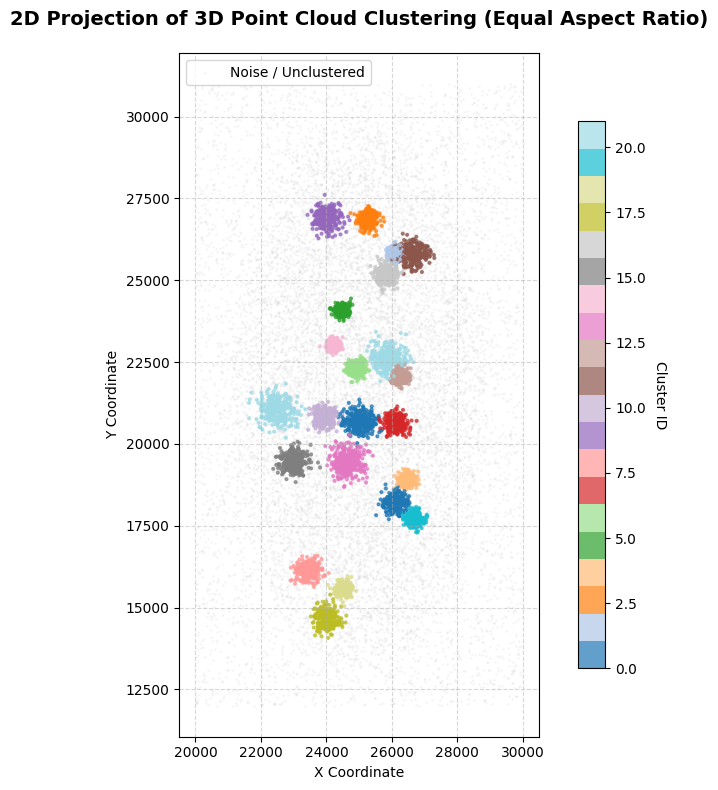

In [8]:
import matplotlib.pyplot as plt

# Downsample to 20,000 points for fluid rendering in the notebook
sample_df = df.sample(n=20000, random_state=42)

fig = plt.figure(figsize=(10, 8), dpi=100)
ax = fig.add_subplot(111)

# Separate noise (-1) and clusters (0 to 21)
noise = sample_df[sample_df['cluster'] == -1]
clusters = sample_df[sample_df['cluster'] != -1]

# Plot noise points in light gray with very low opacity
ax.scatter(noise['x'], noise['y'], c='#d3d3d3', alpha=0.15, s=1, label='Noise / Unclustered')

# Plot cluster points colored by cluster ID using tab20 colormap
scatter = ax.scatter(clusters['x'], clusters['y'], 
                     c=clusters['cluster'], cmap='tab20', alpha=0.7, s=4)
                     
# Add a colorbar to guide cluster identification
cbar = fig.colorbar(scatter, ax=ax, pad=0.04, shrink=0.8)
cbar.set_label('Cluster ID', rotation=270, labelpad=15)

ax.set_title("2D Projection of 3D Point Cloud Clustering (Equal Aspect Ratio)", fontsize=14, fontweight='bold', pad=20)
ax.set_xlabel("X Coordinate")
ax.set_ylabel("Y Coordinate")
ax.grid(True, linestyle='--', alpha=0.5)

# Keep the spatial proportions of the coordinates equal
ax.set_aspect('equal', adjustable='box')

plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


### 6. Cluster Centroid Distance Analysis
To analyze the relationships between the clusters in 3D space, we will compute the centroid (mean coordinate) of each cluster (excluding the noise cluster `-1`) and calculate the pairwise Euclidean distances between these centroids.


In [9]:
# Filter out noise cluster (-1)
filtered_df = df[df['cluster'] != -1]

# Compute 3D centroids (mean of x, y, z) for each cluster
centroids = filtered_df.groupby('cluster')[['x', 'y', 'z']].mean()

print("Cluster Centroids (3D):")
centroids.round(2)


Cluster Centroids (3D):


,x,y,z
cluster,,,
0,26088.53,18196.50,1771.55
1,25028.91,20658.59,1417.69
2,26065.90,25828.96,746.19
3,25279.23,26866.95,1458.53
4,26464.16,18900.28,1052.39
5,24469.51,24096.49,472.19
6,24927.91,22303.69,1454.63
7,26119.24,20621.08,1771.91
8,23445.37,16131.19,719.32


In [10]:
from scipy.spatial.distance import pdist, squareform

# Compute pairwise Euclidean distances between centroids
distances = pdist(centroids.values, metric='euclidean')
distance_matrix = squareform(distances)

# Create a DataFrame representation for clean display
dist_df = pd.DataFrame(
    distance_matrix, 
    index=centroids.index, 
    columns=centroids.index
)

print("Pairwise Centroid Distance Table:")
# Set pandas options to display all columns clearly
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 1000)
dist_df.round(2)


Pairwise Centroid Distance Table:


cluster,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,19,20,21
cluster,,,,,,,,,,,,,,,,,,,,,,
0,0.00,2703.68,7701.05,8713.76,1074.06,6254.55,4279.77,2424.78,3515.53,8942.47,3382.08,7640.46,3888.40,1978.62,5208.82,3371.38,7024.33,4170.90,3123.08,1420.33,4552.47,4624.05
1,2703.68,0.00,5315.91,6213.54,2298.92,3609.16,1648.62,1147.04,4846.92,6311.47,1143.89,5432.27,1879.21,1292.69,2509.37,2358.11,4650.93,6110.71,5132.29,3493.02,2245.56,2564.24
2,7701.05,5315.91,0.00,1484.49,6946.86,2371.70,3771.52,5308.19,10045.63,2405.35,5539.11,1304.19,3828.63,6549.91,3374.17,7091.08,1336.16,11382.47,10402.34,8155.99,3206.56,5964.58
3,8713.76,6213.54,1484.49,0.00,8064.54,3050.23,4576.76,6309.89,10916.32,1265.91,6208.16,1802.31,4907.69,7455.80,4006.79,7739.37,1797.32,12296.35,11339.42,9317.14,4339.04,6438.21
4,1074.06,2298.92,6946.86,8064.54,0.00,5596.05,3755.67,1896.80,4109.98,8363.06,3237.95,6968.11,3186.45,1870.49,4681.42,3539.20,6403.96,4918.95,3879.24,1309.45,3785.71,4510.98
5,6254.55,3609.16,2371.70,3050.23,5596.05,0.00,2095.10,4060.71,8034.67,2983.00,3562.21,3137.49,2875.34,4710.31,1267.00,4942.74,2269.18,9489.38,8575.19,6771.61,2053.01,3683.00
6,4279.77,1648.62,3771.52,4576.76,3755.67,2095.10,0.00,2085.93,6390.50,4674.56,1811.52,3945.04,1372.73,2888.15,1058.83,3429.97,3079.54,7724.71,6764.24,5005.59,1225.30,2733.57
7,2424.78,1147.04,5308.19,6309.89,1896.80,4060.71,2085.93,0.00,5330.73,6620.33,2184.45,5223.43,1497.20,1960.76,3123.10,3352.77,4604.90,6375.27,5341.85,3205.97,2264.80,3685.72
8,3515.53,4846.92,10045.63,10916.32,4109.98,8034.67,6390.50,5330.73,0.00,10794.54,4816.48,10274.26,6607.96,3559.50,6940.13,3443.28,9464.86,1643.16,1315.81,3600.10,6936.97,5041.24


In [11]:
# Display a summary of closest cluster pairs
closest_pairs = []
for i, cluster_id in enumerate(centroids.index):
    row_distances = distance_matrix[i].copy()
    row_distances[i] = np.inf
    nearest_idx = np.argmin(row_distances)
    nearest_cluster = centroids.index[nearest_idx]
    min_dist = row_distances[nearest_idx]
    closest_pairs.append((cluster_id, nearest_cluster, min_dist))
    
closest_pairs.sort(key=lambda x: x[2])
print("Top 5 Closest Cluster Pairs:")
for cluster_a, cluster_b, dist in closest_pairs[:5]:
    print(f"  Cluster {cluster_a:2d} <-> Cluster {cluster_b:2d} | Distance: {dist:.2f}")


Top 5 Closest Cluster Pairs:
  Cluster 12 <-> Cluster 20 | Distance: 949.30
  Cluster 20 <-> Cluster 12 | Distance: 949.30
  Cluster 11 <-> Cluster 16 | Distance: 1038.38
  Cluster 16 <-> Cluster 11 | Distance: 1038.38
  Cluster 17 <-> Cluster 18 | Distance: 1049.94


### 7. Centroid Distance Distribution
To analyze the overall distribution of the cluster separations, we extract the unique pairwise distances (corresponding to the upper triangle of the distance matrix, skipping the zero diagonal values) and visualize them as a histogram.


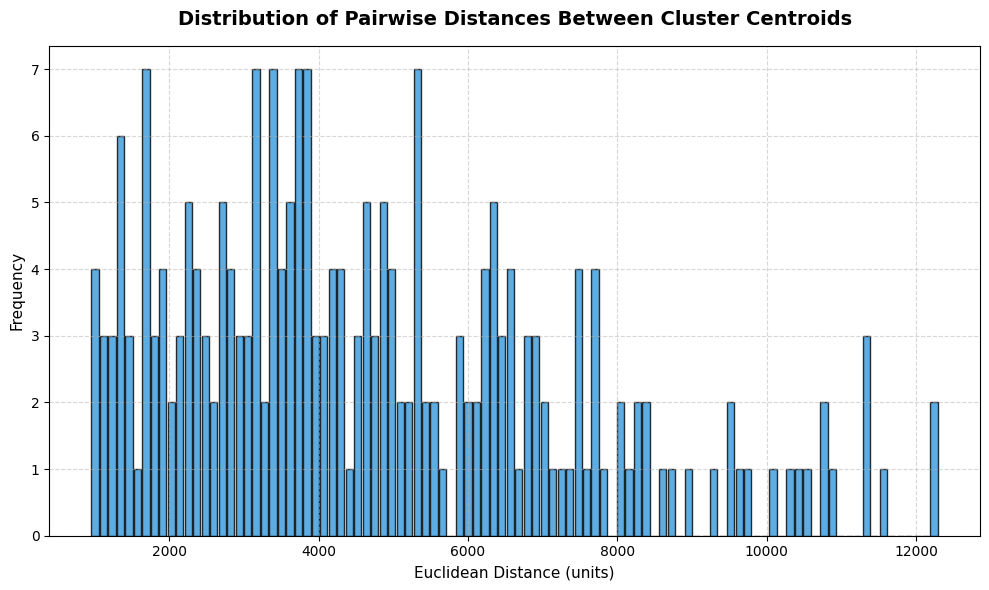

In [13]:
# Extract unique pairwise distances (upper triangle indices with k=1 to exclude the diagonal)
n = distance_matrix.shape[0]
upper_tri_indices = np.triu_indices(n, k=1)
unique_distances = distance_matrix[upper_tri_indices]

# Plot the distribution of unique pairwise distances
plt.figure(figsize=(10, 6), dpi=100)
plt.hist(unique_distances, bins=100, color='#3498db', edgecolor='black', alpha=0.8, rwidth=0.85)

plt.title("Distribution of Pairwise Distances Between Cluster Centroids", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Euclidean Distance (units)", fontsize=11)
plt.ylabel("Frequency", fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()
